# Exploration des données Open Food Facts pour Santé publique France

## Analyse exploratoire

### Table des matières

   * [1. Visualisation des distributions](#section_5_1)
   * [2. Analyse multivariée](#section_5_2)
   * [3. Hypothèses](#section_5_3)
   * [4. Anova](#section_5_4)
   * [5. ACP](#section_5_5)


In [1]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

plt.style.use('seaborn')

In [2]:
data_path = "./data/"
datas = pd.read_csv(data_path + "fr.openfoodfacts.org.products_cleaned.csv", low_memory=False)

In [3]:
nutrition_columns = datas.filter(regex=(".*_100g")).columns 

In [4]:

# définition des colonnes selon leurs unités

# rappel : nutrition_columns représente les colonnes du jeu de données dont le nom finit par "_100g"

# parmi ces colonnes:

# colonnes dont l'unité est le milligramme
# nutri_unite_mg = ['vitamin-c_100g','calcium_100g','cholesterol_100g','iron_100g']
nutri_unite_mg = []

# colonnes dont l'unité est le microgramme
# nutri_unite_ug = ['vitamin-a_100g']
nutri_unite_ug = []

# colonnes dont l'unité n'est pas une masse
nutri_energy = ['energy_100g']
nutri_score = ['nutrition-score-fr_100g']

# colonnes dont l'unité est le gramme
nutri_unite_g = [col for col in nutrition_columns if col not in (nutri_unite_mg + nutri_unite_ug + nutri_energy + nutri_score)]




In [5]:
nutri_list = nutri_unite_g + nutri_unite_mg + nutri_unite_ug + nutri_energy

### 1 - Visualisation des distributions <a class="anchor" id="section_5_1"></a>

#### Les informations nutritionnelles

In [6]:

def graph_quantitatives(df):
    graph_rows = 3
    graph_columns = 3
    fig, axs = plt.subplots(graph_rows, graph_columns, figsize=(15, 15))
    current_row = 0
    current_column = 0

    for col in nutri_list:
        ax = sns.histplot(data=datas, x=col, kde=True, ax=axs[current_row, current_column])
        current_column+=1
        if current_column == graph_columns:
            current_row+=1
            current_column=0

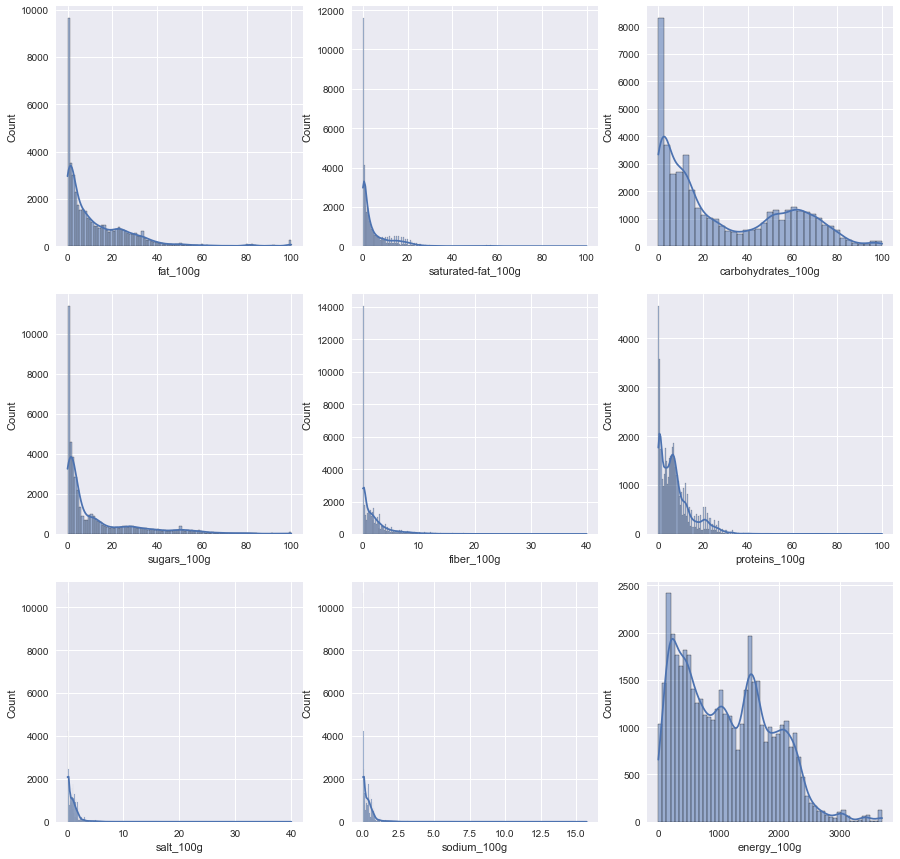

In [7]:

graph_quantitatives(datas)


Les distributions ne suivent pas la loi normale.  
Les distributions de l'énergie et des carbohydrates sont bimodales.  
Les distributions des autres nutriments sont asymétriques et étalées à droite.
Le mode est à 0.

#### Le nutriscore

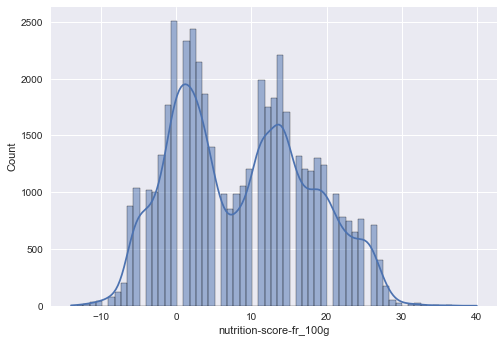

In [8]:
ax = sns.histplot(data=datas, x='nutrition-score-fr_100g', kde=True)


Les valeurs vont de -15 à 40, ce qui est conforme à la théorie:  
Nutri-Score A : -15 à -1  
Nutri-Score B : 0 à 2  
Nutri-Score C : 3 à 10  
Nutri-Score D : 11 à 18  
Nutri-Score E : 19 à 40  

La distribution est bimodale.

#### Le nutrigrade

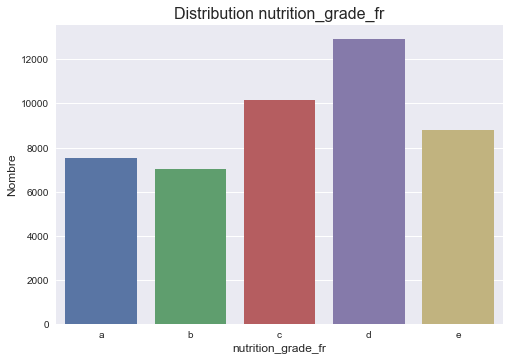

In [9]:
ax = sns.countplot(x="nutrition_grade_fr", data=datas, order=['a','b','c','d','e'])
plt.xlabel('nutrition_grade_fr', fontsize=12)
plt.ylabel('Nombre', fontsize=12)
plt.title('Distribution nutrition_grade_fr', fontsize=16)
plt.show()

La répartition des nutrigrades est assez uniforme.  
Il n'y a pas un grade sous ou sur représenté.  
Le grade le plus représenté est 'd' et le moins représenté est 'b'

### 2 - Analyse multivariée <a class="anchor" id="section_5_2"></a>

Le graphique dynamique suivant permet de visualiser à partir d'une colonne choisie (abscisse):  
Sa distribution selon le nutrigrade
Le nuage de points en fonction d'une deuxième colonne choisie (ordonnée) catégorisé selon le nutrigrade.

Ces graphiques permettent de visualiser le comportement d'une variable quantitative selon une autre variable et le nutrigrade.

Le focus de l'analyse sera fait sur le comportement des nutriments en fonction du nutriscore (quantitatif).  

In [10]:
import ipywidgets as widgets
from ipywidgets import interact, interact_manual, FloatSlider, IntSlider
from ipywidgets import Button, HBox, VBox

grades = np.unique(np.array(datas['nutrition_grade_fr']))

x_col=list(nutrition_columns)
y_col=list(nutrition_columns)
bins_values = IntSlider(value=10,description='bins',min=1,max=20,step=1)
kde_value = widgets.Checkbox(description='kde',)

def multivariate_graphs(abscisse, ordonnee, bins, kde):
    graph_rows = 1
    graph_columns = 5
    fig, axs = plt.subplots(graph_rows, graph_columns, figsize=(15, 5))
    i=0
    for grade in grades:
        ax = sns.histplot(datas[datas['nutrition_grade_fr']==grade], x=abscisse,kde=kde, bins=bins,hue="nutrition_grade_fr",ax=axs[i])
        i+=1
    plt.figure(figsize=(8,5))
    sns.scatterplot(data=datas, x=abscisse, y=ordonnee,hue="nutrition_grade_fr",hue_order=['a','b','c','d','e'],alpha=1)


interact(multivariate_graphs, abscisse=x_col,ordonnee=y_col,bins=bins_values,kde=kde_value)





interactive(children=(Dropdown(description='abscisse', options=('energy_100g', 'fat_100g', 'saturated-fat_100g…

<function __main__.multivariate_graphs(abscisse, ordonnee, bins, kde)>

L'analyse en fonction du nutriscore permet de voir:  

- Pour l'énergie, le gras, le gras saturé et les sucres:
  - lorsque la quantité augmente:
    - le nombre d'individus avec le grade 'a' diminue
    - il n'y a plus de grade 'a' dans les hautes valeurs
  - toutes les valeurs de nutriscores (et grade) sont représentées pour les faibles valeurs
  - les nutriscores élevés, (ou grades d,e) restent toutefois stables quelle que soit la quantité de ces nutriments (et énergie)
  
  --> ces nutriments influent sur le nutriscore, cependant leur absence n'influe pas sur le nutriscore
  
  
- La même observation peut être faite pour le sel et le sodium, mais à la différence qu'il existe peu d'individus avec de grandes quantités de ces nutriments.  
La différence avec peu ou pas de sel est moins marquée qu'avec les informations précédentes.


- Pour les fibres, plus il y en a, moins il y a de grade e, ou de score élevé.  
Toutefois, dans les faibles quantités de fibres, on observe la présence de tous les grades, dans des proportions similaires.  

  --> la présence de fibres influe positivement sur le score, toutefois son absence n'évite pas de mauvais scores.    
  
  
- Sur les graphes avec les carbohydates et les protéines, on n'observe pas de corrélation.

- On observe une corrélation linéaire entre le sel et le sodium.  
- On observe aussi une coorélation entre le nutriscore (quantitatif) et le nutrigrade (qualitatif).



#### Matrice de corrélation:

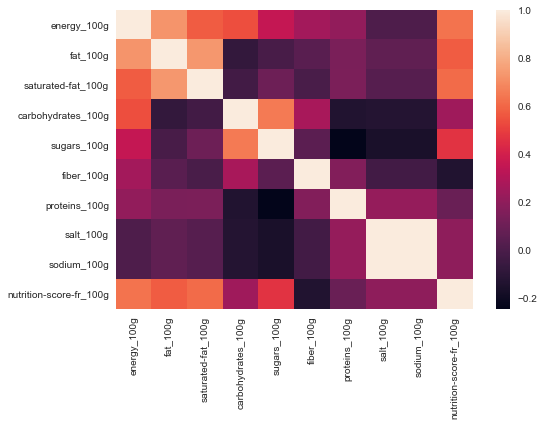

In [11]:
ax = sns.heatmap(datas.corr())

Les nutriments les plus corrélés avec le nutriscore (quantitatif) sont l'énergie, les gras et gras saturés.  
La coefficient de corrélation entre le sel et le sdium est de 1.

### 3 - Hypothèses <a class="anchor" id="section_5_3"></a>

Dans les graphiques à nuages de points, le nutrigrade (qualitatif) semble corrélé avec plusieurs nutriments.  
Le nutrigrade apparait aussi corrélé avec le nutriscore (quantitatif).  
La matrice de corrélation montre des coefficients plus élevés pour la corrélation entre le nutriscore et l'énergie, les gras et gras saturés.  

Hypothèses:  

- La corrélation entre le nutriscore et le nutrigrade est élevée.  
L'énergie, le gras et le gras saturés sont aussi corrélés avec le nutrigrade.

  --> Afin de vérifier que certains nutriments influencent plus ou moins le nutrigrade (qualitatif),
une analyse de la variance (ANOVA) va être réalisée.  


- L'ensemble des nutriments semblent influer sur le nutriscore, de manière différente.  
  Ces nutriments semblent avoir des liens entre eux, comme les gras et gras saturés ou les glucides et les sucres.  
  Le regroupement ou l'association de ces nutriments peuvent aussi influer sur le nutriscore et le nutrigrade.  

  --> Une analyse en composante principales va être effectuée afin de créer des variables synthétiques et d'analyser le jeu de données avec ces nouvelles variables.



### 4 - Anova <a class="anchor" id="section_5_4"></a>

In [12]:

def nutrition_groupes(col):
    X = "nutrition_grade_fr" # qualitative
    Y = col # quantitative
    modalites = datas[X].unique()
    groupes=dict()
    for m in modalites:
        groupes[m]=datas[datas[X]==m][Y]
    return groupes

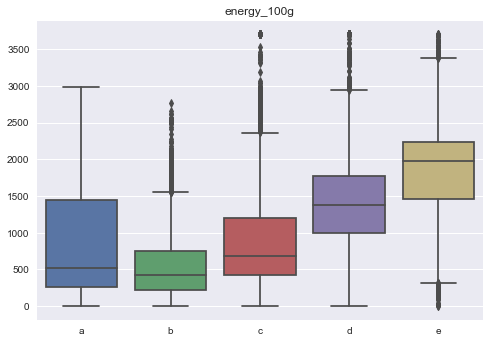

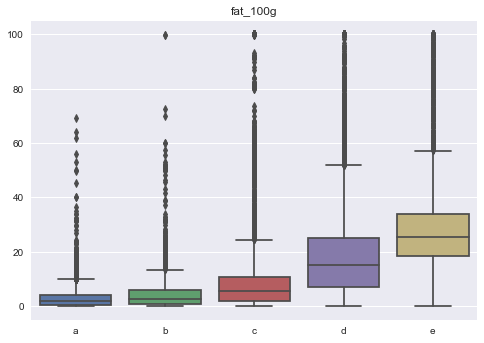

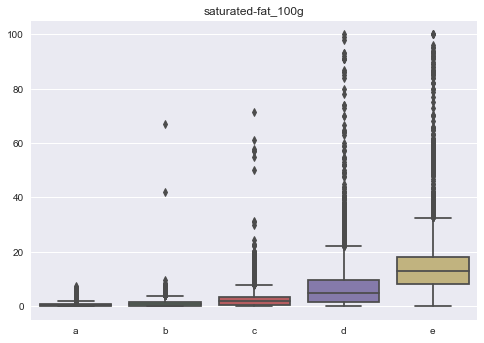

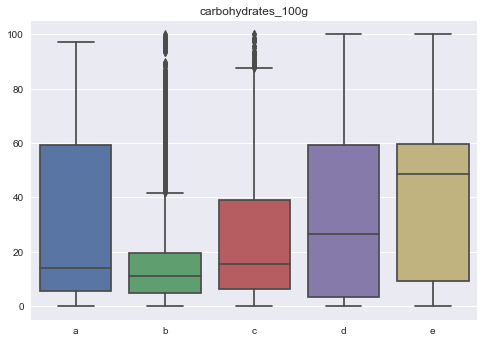

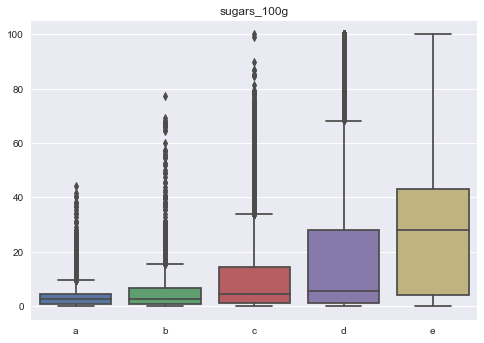

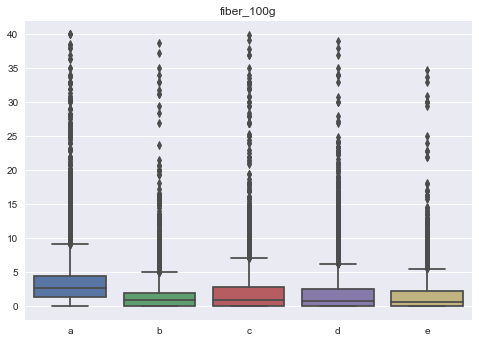

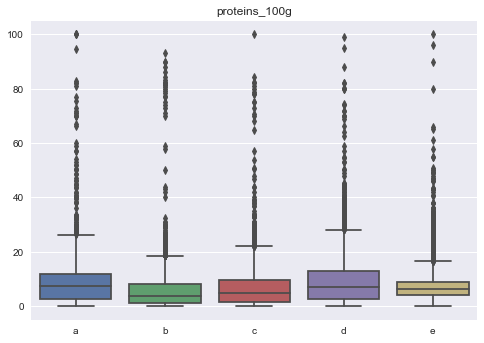

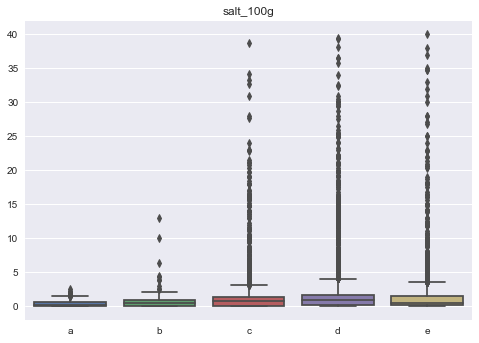

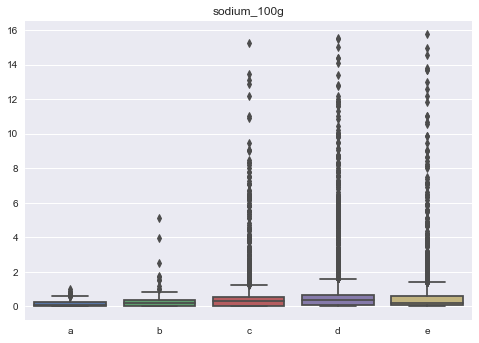

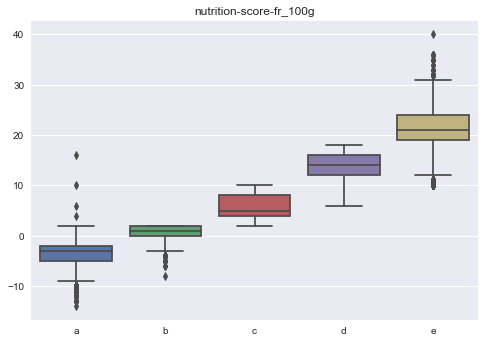

In [13]:
#for col in nutri_list:
for col in nutrition_columns:
    plt.figure()
    df_groupes=pd.DataFrame(nutrition_groupes(col))
    sns.boxplot(data=df_groupes.sort_index(axis = 1, ascending = True)).set_title(col)


Le nutrigrade ne semble pas être beaucoup influencé par les protéines, le sel, le sodium, les carbohydrates, les fibres.  
En revanche, la dispersion de l'énergie et des lipides (fat, saturated fat) semble corrélée au nutrigrade.

Le tableau suivant affiche les valeurs 'eta carré' et 'p value':

In [14]:
import statsmodels.api as sm
from statsmodels.formula.api import ols

In [15]:
# calcul anova
def anova_table(col1,col2):
    lm = ols(col1 + '~' + col2,data=datas).fit()
    table = sm.stats.anova_lm(lm)
    return table

In [16]:
# calcul du rapport de corrélation
def rapport_corelation(table):
    sce = table["sum_sq"]["nutrition_grade_fr"]
    scr = table["sum_sq"]["Residual"]
    sct = sce + scr
    eta_squared = sce/sct
    return eta_squared

In [17]:
# création d'une dataframe pour contenir les informations recueillies 
columns_df = ['colonne','rapport corelation','pvalue']
df_anova = pd.DataFrame(columns=columns_df)

In [18]:
# la fonction ols ne fonctionne pas avec le symbole '-' dans le nom des colonnes
datas.rename(columns={'saturated-fat_100g': 'saturated_fat_100g'}, inplace=True)
datas.rename(columns={'nutrition-score-fr_100g': 'nutrition_score_fr_100g'}, inplace=True)
nutrition_columns = ['saturated_fat_100g' if value=='saturated-fat_100g' else value for value in nutrition_columns]
nutrition_columns = ['nutrition_score_fr_100g' if value=='nutrition-score-fr_100g' else value for value in nutrition_columns]

# calcul des valeurs pour chaque colonne
for col in nutrition_columns:
    table = anova_table(col,'nutrition_grade_fr')
    corelation = rapport_corelation(table)
    pvalue=table["PR(>F)"]["nutrition_grade_fr"]
    df_new_line = pd.DataFrame([[col,corelation,pvalue]], columns=columns_df)    
    df_anova = pd.concat([df_anova,df_new_line], ignore_index=True)

In [19]:
df_anova.sort_values(by=['rapport corelation'], ascending=False)

,colonne,rapport corelation,pvalue
9,nutrition_score_fr_100g,0.913732,0.000000e+00
2,saturated_fat_100g,0.344294,0.000000e+00
0,energy_100g,0.336404,0.000000e+00
1,fat_100g,0.279588,0.000000e+00
4,sugars_100g,0.185499,0.000000e+00
3,carbohydrates_100g,0.058802,0.000000e+00
5,fiber_100g,0.051247,0.000000e+00
7,salt_100g,0.040848,0.000000e+00
8,sodium_100g,0.040848,0.000000e+00
6,proteins_100g,0.019975,2.181312e-201


On peut observer que les coefficients de corrélation pour les lipides et l'énergie sont bien plus élevés que pour les autres nutriments.  
Ce qui confirme les observations précédentes.  
Le coefficient de corrélation entre le nutriscore et le nutrigrade est presque de 1.  

Hypothèse nulle : la distribution du nutriment est similaire quel que soit le nutrigrade.  
La p value est de 0, l'hypothèse nulle est rejetée.  
Ces nutriments impactent le nutrigrade.


In [20]:
datas.rename(columns={'saturated_fat_100g': 'saturated-fat_100g'}, inplace=True)
datas.rename(columns={'nutrition_score_fr_100g': 'nutrition-score-fr_100g'}, inplace=True)
nutrition_columns = ['saturated-fat_100g' if value=='saturated_fat_100g' else value for value in nutrition_columns]
nutrition_columns = ['nutrition-score-fr_100g' if value=='nutrition_score_fr_100g' else value for value in nutrition_columns]


### 5 - ACP <a class="anchor" id="section_5_5"></a>

In [21]:
from sklearn import preprocessing

std_scale = preprocessing.StandardScaler().fit(datas[nutrition_columns])
datas_scaled = std_scale.transform(datas[nutrition_columns])
datas_scaled = pd.DataFrame(datas_scaled,datas[nutrition_columns].index,datas[nutrition_columns].columns)

datas = pd.concat([datas_scaled,datas[['product_name','nutrition_grade_fr']]],axis=1)


In [22]:
import matplotlib.pyplot as plt
from matplotlib.collections import LineCollection
import numpy as np
import pandas as pd

def display_circles(pcs, n_comp, pca, axis_ranks, labels=None, label_rotation=0, lims=None):
    for d1, d2 in axis_ranks: # On affiche les 3 premiers plans factoriels, donc les 6 premières composantes
        if d2 < n_comp:

            # initialisation de la figure
            fig, ax = plt.subplots(figsize=(7,6))

            # détermination des limites du graphique
            if lims is not None :
                xmin, xmax, ymin, ymax = lims
            elif pcs.shape[1] < 30 :
                xmin, xmax, ymin, ymax = -1, 1, -1, 1
            else :
                xmin, xmax, ymin, ymax = min(pcs[d1,:]), max(pcs[d1,:]), min(pcs[d2,:]), max(pcs[d2,:])

            # affichage des flèches
            # s'il y a plus de 30 flèches, on n'affiche pas le triangle à leur extrémité
            if pcs.shape[1] < 30 :
                plt.quiver(np.zeros(pcs.shape[1]), np.zeros(pcs.shape[1]),
                   pcs[d1,:], pcs[d2,:], 
                   angles='xy', scale_units='xy', scale=1, color="grey")
                # (voir la doc : https://matplotlib.org/api/_as_gen/matplotlib.pyplot.quiver.html)
            else:
                lines = [[[0,0],[x,y]] for x,y in pcs[[d1,d2]].T]
                ax.add_collection(LineCollection(lines, axes=ax, alpha=.1, color='black'))
            
            # affichage des noms des variables  
            if labels is not None:  
                for i,(x, y) in enumerate(pcs[[d1,d2]].T):
                    if x >= xmin and x <= xmax and y >= ymin and y <= ymax :
                        plt.text(x, y, labels[i], fontsize='14', ha='center', va='center', rotation=label_rotation, color="blue", alpha=0.5)
            
            # affichage du cercle
            circle = plt.Circle((0,0), 1, facecolor='none', edgecolor='b')
            plt.gca().add_artist(circle)

            # définition des limites du graphique
            plt.xlim(xmin, xmax)
            plt.ylim(ymin, ymax)
        
            # affichage des lignes horizontales et verticales
            plt.plot([-1, 1], [0, 0], color='grey', ls='--')
            plt.plot([0, 0], [-1, 1], color='grey', ls='--')

            # nom des axes, avec le pourcentage d'inertie expliqué
            plt.xlabel('F{} ({}%)'.format(d1+1, round(100*pca.explained_variance_ratio_[d1],1)))
            plt.ylabel('F{} ({}%)'.format(d2+1, round(100*pca.explained_variance_ratio_[d2],1)))

            plt.title("Cercle des corrélations (F{} et F{})".format(d1+1, d2+1))
            plt.show(block=False)
        
def display_factorial_planes(X_projected, n_comp, pca, axis_ranks, labels=None, alpha=1, illustrative_var=None,filter_value='all'):
    for d1,d2 in axis_ranks:
        if d2 < n_comp:
 
            # initialisation de la figure       
            fig = plt.figure(figsize=(7,6))
        
            # affichage des points
            if illustrative_var is None:
                plt.scatter(X_projected[:, d1], X_projected[:, d2], alpha=alpha)
            else:
                illustrative_var = np.array(illustrative_var)
                for value in np.unique(illustrative_var):
                    if (value in np.array(filter_value)) | (filter_value == 'all'):
                        selected = np.where(illustrative_var == value)
                        ax = plt.scatter(X_projected[selected, d1], X_projected[selected, d2], alpha=alpha, label=value)
                plt.legend()

            # affichage des labels des points
            if labels is not None:
                for i,(x,y) in enumerate(X_projected[:,[d1,d2]]):
                    plt.text(x, y, labels[i],
                              fontsize='14', ha='center',va='center') 
                
            # détermination des limites du graphique
            boundary = np.max(np.abs(X_projected[:, [d1,d2]])) * 1.1
            plt.xlim([-boundary,boundary])
            plt.ylim([-boundary,boundary])
        
            # affichage des lignes horizontales et verticales
            plt.plot([-100, 100], [0, 0], color='grey', ls='--')
            plt.plot([0, 0], [-100, 100], color='grey', ls='--')

            # nom des axes, avec le pourcentage d'inertie expliqué
            plt.xlabel('F{} ({}%)'.format(d1+1, round(100*pca.explained_variance_ratio_[d1],1)))
            plt.ylabel('F{} ({}%)'.format(d2+1, round(100*pca.explained_variance_ratio_[d2],1)))

            plt.title("Projection des individus (sur F{} et F{})".format(d1+1, d2+1))
            plt.show(block=False)

def display_scree_plot(pca):
    scree = pca.explained_variance_ratio_*100
    plt.bar(np.arange(len(scree))+1, scree)
    plt.plot(np.arange(len(scree))+1, scree.cumsum(),c="red",marker='o')
    plt.xlabel("rang de l'axe d'inertie")
    plt.ylabel("pourcentage d'inertie")
    plt.title("Eboulis des valeurs propres")
    plt.show(block=False)

In [23]:
from sklearn import decomposition

pca = decomposition.PCA(n_components=6)
pca.fit(datas[nutrition_columns])

PCA(n_components=6)

#### Eboulis des valeurs propres


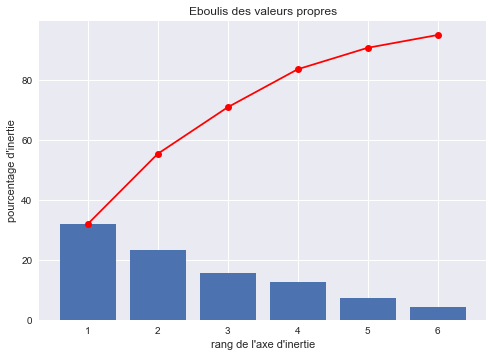

In [24]:
display_scree_plot(pca)

Plus de 80% de l'inertie est représentée avec les 4 premières composantes.  
L'analyse se basera sur ces 4 composantes.

#### Cercle des corrélations

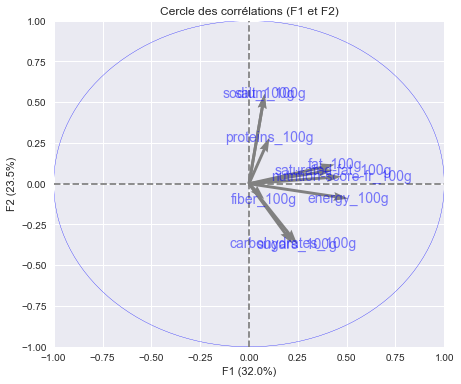

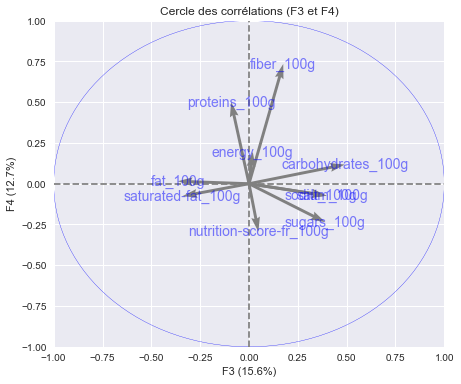

In [25]:
#%matplotlib notebook

# Cercle des corrélations
pcs = pca.components_
display_circles(pcs, 6, pca, [(0,1),(2,3)], labels = np.array(nutrition_columns))


- Sur le premier cercle, axes F1 et F2:

On observe un goupe composé de l'énergie, le nutriscore, le gras et le gras saturé.  
Les flèches sont proches de l'axe F1 (angle) et leurs projections sur cet axe sont d'environ 0.5.  

Le sel, le sodium sont proches de l'axe F2 vers le haut,  
tandis que le sucre et les glucides, plus proches de l'axe F2 que de F1, sont dirigés vers le bas.  

Les lipides (gras, gras saturé) sont les nutriments les plus calorifiques, et qui apportent le plus d'énergie.  
***L'axe F1 peut représenter cet aspect calorifique, énergétique.***  
***L'axe F2 peut représenter l'aspect sucré/salé.***


- Sur le deuxième cercle, axes F3 et F4:  

Sucres, glucides,sel, sodium sont corélés à l'axe F3 dans le sens positif et  
les lipides sont aussi corélés à F3, dans le sens négatif.  

Les glucides sont rapidement digérés pour la plupart.  
Inversement, les lipides permettent de rallonger le temps de digestion.  
***L'axe F3 peut ainsi représenter le temps de digestion.***

Les fibres sont bien corrélées à l'axe F4, les protéines aussi dans une moindre mesure.  
Ce sont les nutriments qui atténuent le plus la sensation de faim, qui agissent le plus sur la satiété.  
***L'axe F4 peut ainsi représenter la satiété.***


- Autre observation sur les deux cercles:  

On voit aussi que:  
Le sel et le sodium sont confondus sur les deux cercles. Ces nutriments sont très corrélés.  
Le sucre et les glucides (carbohydrates) sont corrélés sur le premier cercle et un peu moins sur le deuxième.  






#### projection des individus

In [26]:
X_projected = pca.transform(datas[nutrition_columns])


In [27]:
grades_acp = np.array('all')
grades_acp = np.append(grades_acp,np.unique(np.array(datas['nutrition_grade_fr'])))

nutrigrade_list = widgets.SelectMultiple(
    options=['a', 'b', 'c', 'd', 'e'],
    value=['a'],
    #rows=10,
    description='Nutrigrade',
    disabled=False
)

alpha_values = FloatSlider(value=1,description='Transparence',min=0,max=1,step=0.1)


@interact
def show_articles_more_than(grade=nutrigrade_list,alpha_value=alpha_values):
    display_factorial_planes(X_projected, 6, pca, [(0,1),(2,3)], illustrative_var = datas['nutrition_grade_fr'],filter_value=grade,alpha=alpha_value)
    



interactive(children=(SelectMultiple(description='Nutrigrade', index=(0,), options=('a', 'b', 'c', 'd', 'e'), …

Les axes:
- F1 energetique
- F2 sucré/salé
- F3 temps de digestion
- F4 satiété

Les individus avec un nutriscore 'a' sont:
  - centrés sur le graphique avec les axes F1 et F2.
  - dispersés le long de l'axe F4.

En faisant évoluer le nutrigrade de 'a' vers 'e', on observe:
- de plus en plus d'individus sur l'axe F2 positivement, c'est à dire avec un caractère salé.
- de plus en plus d'individus sur l'axe F3 positivement, c'est à dire avec un temps de digestion long.
- de moins en moins d'individus sur l'axe F4 positivement, c'est à dire avec une satiété qui diminue.


En comparant les nutrigrades par deux, sur le graphique avec les axes F1 et F2:
- Le nutrigrade supérieur recouvre le nutrigrade précédent et s'étend positivement vers F1 et F2



**Sur le graphique avec les axes F1 et F2 :**

On constate que lorsque les valeurs sont importantes sur les axes, on n'a pas de bon nutrigrade (valeur 'a').  
Si elles sont faibles, on a tous les nutrigrades.  

On observe donc qu'avec des valeurs importantes sur les axes F1 et F2, le nutriscore est impacté négativement.
En revanche des valeurs faibles ne garantissent pas un bon nutriscore.  
Lorsque les valeurs sont faibles, la répartition est similaire pour chaque grade, il n'y a pas de corrélation.

**Sur le graphique avec les axes F3 et F4 :**

Le nutriscore est impacté positivement lorsque les aliments diminuent la sensation de faim.    
Il est impacté négativement lorsque les aliments se digèrent rapidement.  

